In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Gerando dados sintéticos estruturados
np.random.seed(42)
n_registros = 120

datas = pd.date_range(start='2024-01-01', periods=n_registros, freq='D')
categorias = ['Eletronicos', 'Livros', 'Roupas', 'Automotivo']
estados = ['SP', 'RJ', 'MG', 'RS', 'BA']

dados = {
    'data': datas,
    'categoria': np.random.choice(categorias, size=n_registros),
    'estado': np.random.choice(estados, size=n_registros),
    'valor': np.random.uniform(50, 4500, size=n_registros).round(2),
    'quantidade': np.random.randint(1, 15, size=n_registros),
}

df = pd.DataFrame(dados)
df['valor_venda'] = (df['valor'] * np.random.uniform(0.9, 1.1, size=n_registros)).round(2)

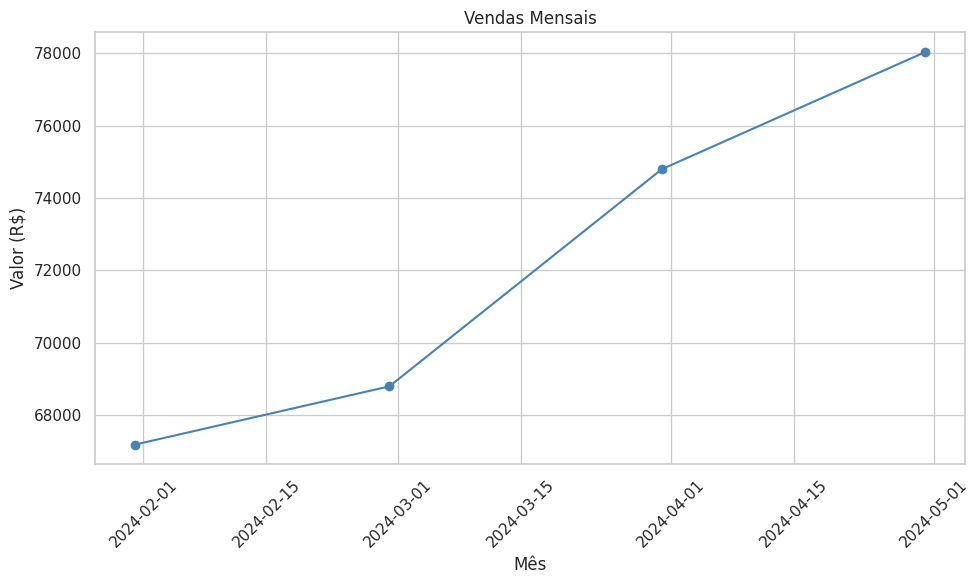

In [5]:
df_mensal = df.set_index('data').resample('ME')['valor_venda'].sum()

plt.figure(figsize=(10, 6))
plt.plot(df_mensal.index, df_mensal.values, marker='o', linestyle='-', color='steelblue')
plt.title('Vendas Mensais')
plt.xlabel('Mês')
plt.ylabel('Valor (R$)')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(8, 4))
plt.bar(vendas_categoria.index, vendas_categoria.values, color='seagreen')
plt.title('Vendas por Categoria')
plt.ylabel('Valor (R$)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

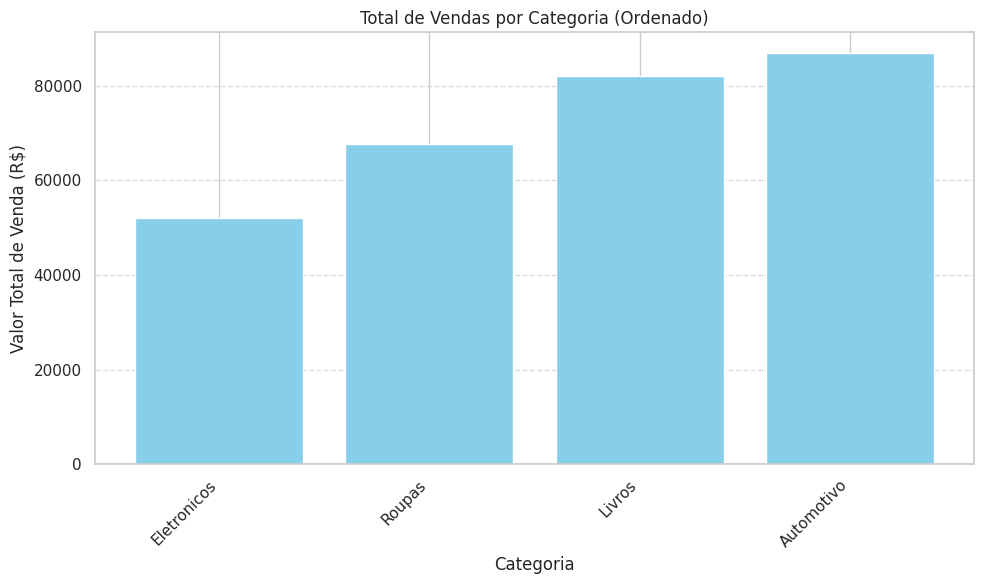

In [6]:
vendas_por_categoria = df.groupby('categoria')['valor_venda'].sum().sort_values()

plt.figure(figsize=(10, 6))
plt.bar(vendas_por_categoria.index, vendas_por_categoria.values, color='skyblue')
plt.title('Total de Vendas por Categoria (Ordenado)')
plt.xlabel('Categoria')
plt.ylabel('Valor Total de Venda (R$)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

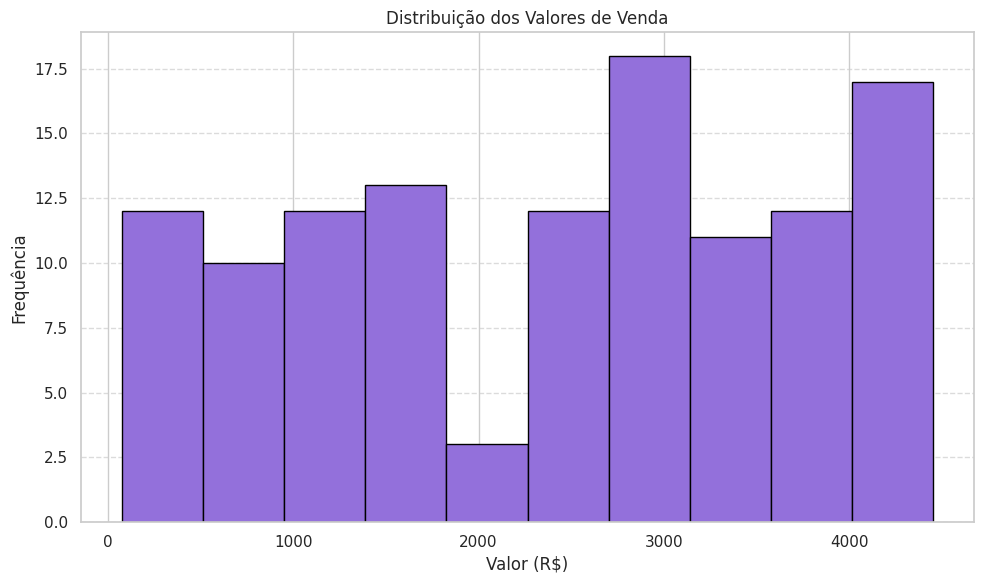

In [7]:
plt.figure(figsize=(10, 6))
plt.hist(df['valor'], bins=10, edgecolor='black', color='mediumpurple')
plt.title('Distribuição dos Valores de Venda')
plt.xlabel('Valor (R$)')
plt.ylabel('Frequência')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

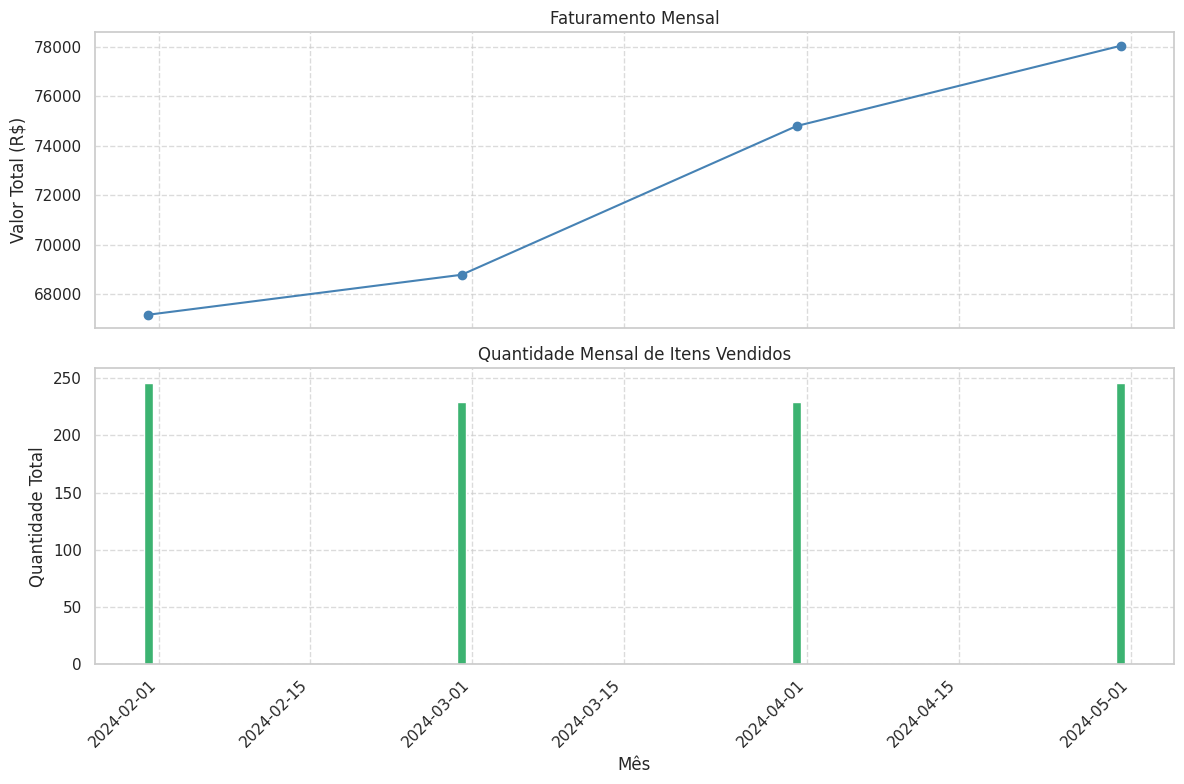

In [8]:
df_mensal_faturamento = df.set_index('data').resample('ME')['valor_venda'].sum()
df_mensal_quantidade = df.set_index('data').resample('ME')['quantidade'].sum()

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(12, 8))

ax1.plot(df_mensal_faturamento.index, df_mensal_faturamento.values, marker='o', linestyle='-', color='steelblue')
ax1.set_title('Faturamento Mensal')
ax1.set_ylabel('Valor Total (R$)')
ax1.grid(True, linestyle='--', alpha=0.7)

ax2.bar(df_mensal_quantidade.index, df_mensal_quantidade.values, color='mediumseagreen')
ax2.set_title('Quantidade Mensal de Itens Vendidos')
ax2.set_xlabel('Mês')
ax2.set_ylabel('Quantidade Total')
ax2.grid(True, linestyle='--', alpha=0.7)

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()